# Project 2 — Part I (a): Will the disease disappear?

*What is the likelihood that the disease will disappear?*

The stochastic SIR model is imported from the local library [`sir_model.py`](sir_model.py): the
**refined Binomial sampling of compartment counts** ("Building the stochastic model — Refining the
model", Section 0.2), the scheme actually adopted in the report rather than the impractical
per-individual loop. This notebook only sets up the experiments and plots. Even when $R_0>1$, a
newly introduced case can fail to ignite an epidemic purely by chance while the number of
infectives is small — a phenomenon the deterministic ODE cannot show.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from sir_model import simulate_sir, final_size, extinction_probability

IMAGES = Path("..") / "Images"
IMAGES.mkdir(exist_ok=True)

# base scenario (as in the report's MATLAB code)
N, gamma, I0 = 1000, 0.1, 1
# extinction is a low-count quantity: at dt=1 the chain-binomial slightly underestimates it
# (a recovering infective can still transmit within a step), so we use a finer dt for estimates
DT = 0.25
print(f"N={N}, gamma={gamma}, I0={I0}, dt={DT}")

N=1000, gamma=0.1, I0=1, dt=0.25


## 1. Stochastic fade-out and its likelihood

While infectives are few, the first cases may recover before infecting anyone, so an outbreak can
die out by chance even when $R_0>1$. We show this directly with a batch of epidemics from a single
case, then estimate how the likelihood of disappearance depends on $R_0$.

We run $M=2000$ independent epidemics from $i_0$ initial cases and call a run a *disappearance*
(minor outbreak) when the final size $N-S(T)$ stays below $1\%$ of $N$; the likelihood is the
fraction of such runs, with $95\%$ confidence intervals (at $\Delta t=0.25$, fine enough that the
time step does not bias this low-count estimate).

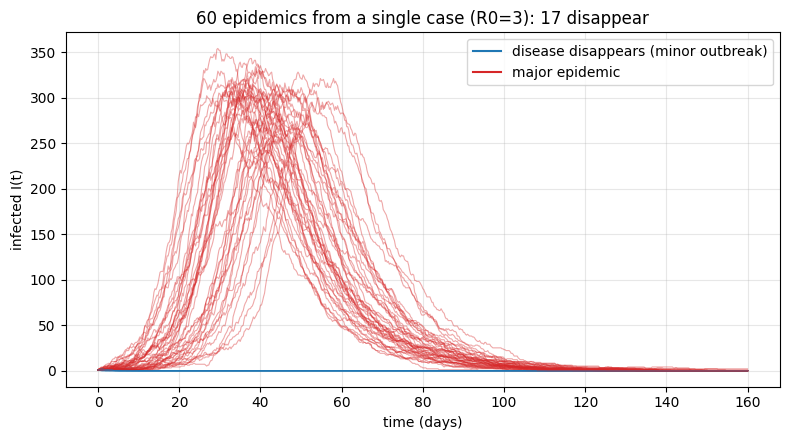

17/60 runs faded out


In [2]:
rng = np.random.default_rng(0)
beta = 3 * gamma            # R0 = 3
T = 160
n_show = 60

plt.figure(figsize=(8, 4.5))
n_minor = 0
for _ in range(n_show):
    time, S, I, _ = simulate_sir(N, beta, gamma, I0, T, DT, rng=rng)
    minor = (N - S[-1]) < 0.01 * N          # final size below 1% of N
    if minor:
        n_minor += 1
        plt.plot(time, I, color="tab:blue", lw=0.8, alpha=0.6)
    else:
        plt.plot(time, I, color="tab:red", lw=0.8, alpha=0.4)
plt.plot([], [], color="tab:blue", label="disease disappears (minor outbreak)")
plt.plot([], [], color="tab:red", label="major epidemic")
plt.xlabel("time (days)"); plt.ylabel("infected I(t)")
plt.title(f"{n_show} epidemics from a single case (R0=3): {n_minor} disappear")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(IMAGES / "Proj2_PartA_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"{n_minor}/{n_show} runs faded out")

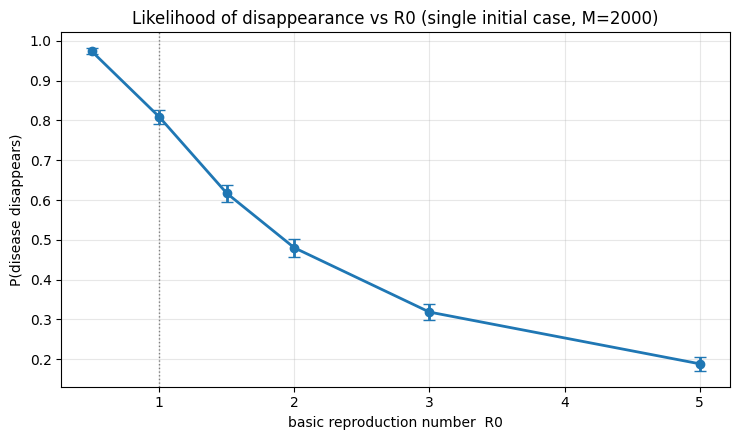

  R0 |   P(disappear) |           95% CI
 0.5 |          0.974 | [0.967, 0.981]
 1.0 |          0.809 | [0.792, 0.826]
 1.5 |          0.617 | [0.596, 0.638]
 2.0 |          0.480 | [0.458, 0.502]
 3.0 |          0.319 | [0.298, 0.339]
 5.0 |          0.189 | [0.171, 0.206]


In [3]:
R0_values = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
M = 2000
p_hat, lo, hi = [], [], []
for R0 in R0_values:
    rng = np.random.default_rng(100)
    p, a, b = extinction_probability(N, R0 * gamma, gamma, I0=I0, T=200, dt=DT,
                                     n_reps=M, threshold=0.01, rng=rng)
    p_hat.append(p); lo.append(a); hi.append(b)
p_hat = np.array(p_hat)
yerr = np.vstack([p_hat - np.array(lo), np.array(hi) - p_hat])

plt.figure(figsize=(7.5, 4.5))
plt.errorbar(R0_values, p_hat, yerr=yerr, fmt="o-", capsize=4, lw=2)
plt.axvline(1.0, color="grey", ls=":", lw=1)
plt.xlabel("basic reproduction number  R0"); plt.ylabel("P(disease disappears)")
plt.title(f"Likelihood of disappearance vs R0 (single initial case, M={M})")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(IMAGES / "Proj2_PartA_extinction_vs_R0.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'R0':>4} | {'P(disappear)':>14} | {'95% CI':>16}")
for R0, p, a, b in zip(R0_values, p_hat, lo, hi):
    print(f"{R0:>4} | {p:>14.3f} | [{a:.3f}, {b:.3f}]")

**Reading.** For $R_0\le1$ the disease essentially always disappears. Above threshold the
likelihood drops as $R_0$ grows: about one outbreak in three still fades out at $R_0=3$, falling
to roughly one in five at $R_0=5$. The deterministic model, by contrast, always predicts an
epidemic when $R_0>1$.

## 2. Effect of the number of initial cases

Repeating the estimate at $R_0=3$ for several numbers of initial infectives $i_0$ shows the
likelihood falling steeply as more cases are introduced (each one would have to die out
independently).

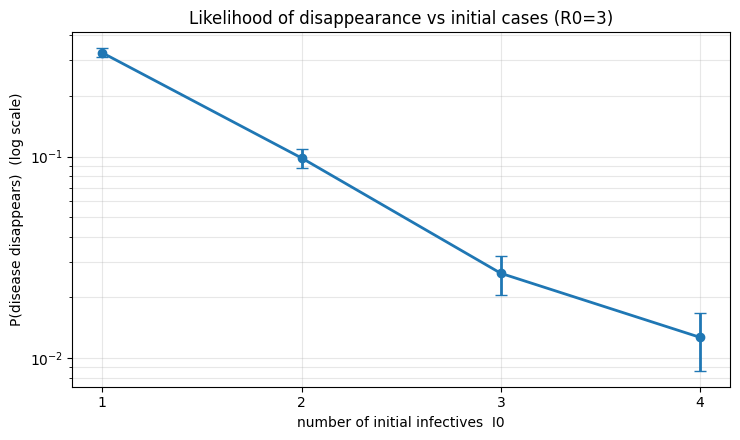

I0=1: P(disappear)=0.327
I0=2: P(disappear)=0.098
I0=3: P(disappear)=0.026
I0=4: P(disappear)=0.013


In [4]:
beta = 3 * gamma            # R0 = 3
I0_values = [1, 2, 3, 4]
p_hat2, lo2, hi2 = [], [], []
for i0 in I0_values:
    rng = np.random.default_rng(200)
    p, a, b = extinction_probability(N, beta, gamma, I0=i0, T=200, dt=DT,
                                     n_reps=3000, threshold=0.01, rng=rng)
    p_hat2.append(p); lo2.append(a); hi2.append(b)
p_hat2 = np.array(p_hat2)
yerr2 = np.vstack([p_hat2 - np.array(lo2), np.array(hi2) - p_hat2])

plt.figure(figsize=(7.5, 4.5))
plt.errorbar(I0_values, p_hat2, yerr=yerr2, fmt="o-", capsize=4, lw=2)
plt.yscale("log"); plt.xticks(I0_values)
plt.xlabel("number of initial infectives  I0"); plt.ylabel("P(disease disappears)  (log scale)")
plt.title("Likelihood of disappearance vs initial cases (R0=3)")
plt.grid(alpha=0.3, which="both"); plt.tight_layout()
plt.savefig(IMAGES / "Proj2_PartA_extinction_vs_I0.png", dpi=150, bbox_inches="tight")
plt.show()

for i0, p in zip(I0_values, p_hat2):
    print(f"I0={i0}: P(disappear)={p:.3f}")

## Conclusion

The disease can disappear by chance even when it is, on average, growing ($R_0>1$). From a single
case it fades out about one time in three at $R_0=3$, less often as $R_0$ increases, and the
likelihood drops steeply with the number of initial cases. This early stochastic fade-out is a
genuinely stochastic effect that the deterministic SIR model cannot reproduce.

---

**AI Declaration:** This notebook's code was refactored and commented with AI assistance. All results and conclusions were independently verified by a human supervisor.